# Portfolio Optimization Using Efficient Frontier

The goal of this project is to construct an efficient portfolio using the Modern Portfolio Theory (MPT) framework. The efficient frontier will be derived using historical stock data and optimized for maximum Sharpe ratio.

Key details:
- Data consists of five major banking stocks from NSE.
- The portfolio is optimized using Monte Carlo simulation.
- The Sharpe ratio is used as a performance metric to find the best risk-return tradeoff.

Required packages:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import pandas as pd

Define stock ticker set (Top 5 banks in NSE)

In [2]:
ticker_set=["HDFCBANK.NS", "ICICIBANK.NS", "SBIN.NS", "KOTAKBANK.NS", "AXISBANK.NS"]

Define time period for analysis

In [3]:
start_date = "2023-01-01"
end_date = "2025-01-01"

Download stock data

In [4]:
stock_data = yf.download(ticker_set, start=start_date, end=end_date)['Close']
stock_return = stock_data.pct_change().dropna()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  5 of 5 completed


Compute annualized returns and covariance matrix

In [5]:
returns = stock_return.mean() * 252
cov_matrix = stock_return.cov() * 252
num_assets = len(ticker_set)
risk_free_rate = 0.03

Monte Carlo simulation for portfolio optimization

In [6]:
num_portfolios = 10**5
all_weights = np.zeros((num_portfolios, num_assets))
ret_arr = np.zeros(num_portfolios)
vol_arr = np.zeros(num_portfolios)
sharpe_arr = np.zeros(num_portfolios)

for i in range(num_portfolios):
    weights = np.random.random(num_assets)
    weights = weights / np.sum(weights)  # Normalize so sum of weights = 1
    
    
    portfolio_return = np.dot(weights, returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix, weights))
    portfolio_std = np.sqrt(portfolio_variance)
    
    
    all_weights[i, :] = weights
    ret_arr[i] = portfolio_return
    vol_arr[i] = portfolio_std
    sharpe_arr[i] = (portfolio_return - risk_free_rate) / portfolio_std

Find the max Sharpe Ratio portfolio

In [7]:
max_sharpe_idx = np.argmax(sharpe_arr)
optimal_weights = all_weights[max_sharpe_idx, :]
optimal_return = ret_arr[max_sharpe_idx]
optimal_risk = vol_arr[max_sharpe_idx]

Plot Efficient Frontier

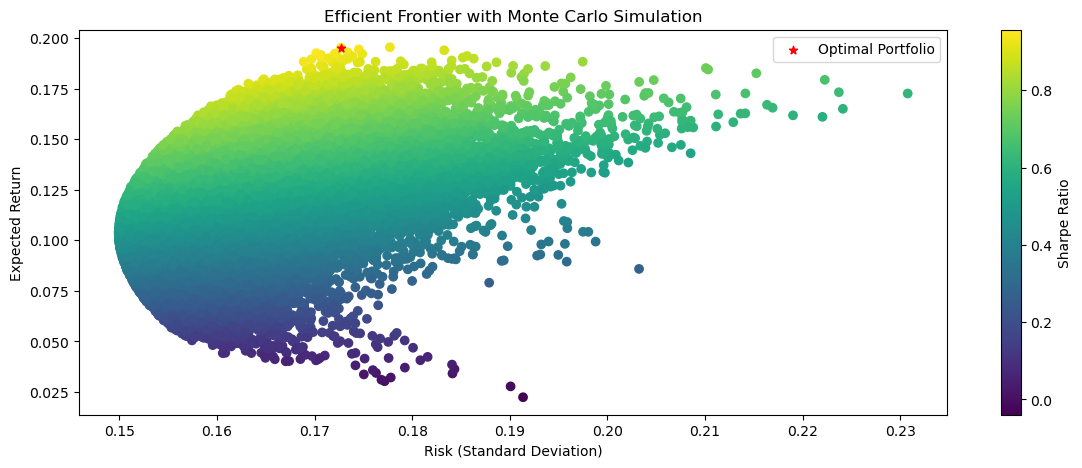

In [8]:
plt.figure(figsize=(14, 5))
plt.scatter(vol_arr, ret_arr, c=sharpe_arr)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(optimal_risk, optimal_return, c='red', marker='*', label='Optimal Portfolio')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier with Monte Carlo Simulation')
plt.legend()
plt.show()

Optimal Portfolio Allocation:

In [9]:
portfolio_df = pd.DataFrame({'Stock': ticker_set, 'Weight': optimal_weights})
portfolio_df = portfolio_df.sort_values(by='Weight', ascending=False)

print("Optimal Portfolio Allocation:")
print(portfolio_df.to_string(index=False))


Optimal Portfolio Allocation:
       Stock   Weight
     SBIN.NS 0.720737
 AXISBANK.NS 0.212204
ICICIBANK.NS 0.039479
KOTAKBANK.NS 0.015034
 HDFCBANK.NS 0.012546
